
# QBER-Aware Quantum-Safe RTGS Orchestration — Revised Reproducible Notebook

This notebook implements a corrected  pipeline.

## Main methodological corrections





In [3]:

# CELL 1 — Install/import dependencies
!pip -q install statsmodels openpyxl

import os, io, json, math, time, warnings, hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats, optimize
from scipy.special import xlogy
from sklearn.metrics import (
    confusion_matrix, classification_report, balanced_accuracy_score,
    precision_recall_fscore_support, roc_auc_score, brier_score_loss
)
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Environment ready.")


Environment ready.


In [4]:

# CELL 2 — Global configuration
PAPER_MODE = False
MASTER_SEED = 2026

N_TX = 5000 if PAPER_MODE else 500
N_RUNS = 100 if PAPER_MODE else 2
BLOCK_LENGTH = 50
N_BOOT = 2000 if PAPER_MODE else 200

# Simplified asymptotic BB84 positive-key boundary is around 0.1100.
# Operational thresholds are kept below that boundary.
THETA_LOW = 0.070
THETA_HIGH = 0.090
QKD_DISABLE_QBER = 0.100

EMA_ALPHA = 0.05
RECOVERY_DWELL = 5

# Key buffer model (abstract normalized key units)
BUFFER_MAX = 2500.0
BUFFER_INITIAL = 1250.0
KEY_CONSUMPTION_PER_TX = 1.0
MIN_BUFFER_FOR_HYBRID = 25.0

# Reproducible random generator
GLOBAL_RNG = np.random.default_rng(MASTER_SEED)

print({
    "PAPER_MODE": PAPER_MODE,
    "N_TX": N_TX,
    "N_RUNS": N_RUNS,
    "QKD_DISABLE_QBER": QKD_DISABLE_QBER
})


{'PAPER_MODE': False, 'N_TX': 500, 'N_RUNS': 2, 'QKD_DISABLE_QBER': 0.1}



## 2. Load the archived benchmark dataset

The loader first checks common Colab/local names, then attempts the GitHub repository.  
The file is described as an **archived synthetic benchmark trace generated by the authors' simulation framework**.


In [5]:

# CELL 3 — Load dataset with local and GitHub fallback
LOCAL_CANDIDATES = [
    "/content/LAYER1_full_benchmark (4).csv",
    "/content/LAYER1_full_benchmark.csv",
    "/mnt/data/LAYER1_full_benchmark (4).csv",
]

GITHUB_URL = (
    "https://raw.githubusercontent.com/"
    "Rnaveennithyakalyan/Adaptive-framework/"
    "main/Dataset/RTGS%20DATA.csv"
)

def load_benchmark_dataset() -> Tuple[pd.DataFrame, str]:
    for p in LOCAL_CANDIDATES:
        if os.path.exists(p):
            return pd.read_csv(p), f"local file: {p}"
    try:
        return pd.read_csv(GITHUB_URL), f"GitHub: {GITHUB_URL}"
    except Exception as exc:
        raise FileNotFoundError(
            "Dataset not found locally and GitHub download failed. "
            "Upload the CSV to Colab and rerun this cell."
        ) from exc

raw_df, DATA_SOURCE = load_benchmark_dataset()

required = {
    "tx_id", "qber", "ch_state", "mode",
    "lat_classical", "lat_proposed", "overhead_ms", "overhead_pct"
}
missing = required.difference(raw_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

raw_df = raw_df.copy()
raw_df["qber"] = pd.to_numeric(raw_df["qber"], errors="coerce")
raw_df["lat_classical"] = pd.to_numeric(raw_df["lat_classical"], errors="coerce")
raw_df["lat_proposed"] = pd.to_numeric(raw_df["lat_proposed"], errors="coerce")
raw_df = raw_df.dropna(subset=["qber", "lat_classical", "lat_proposed"]).reset_index(drop=True)

print(f"Loaded {len(raw_df):,} records from {DATA_SOURCE}")
print("Dataset status: archived synthetic benchmark trace; not external validation.")
display(raw_df.head())


Loaded 5,000 records from GitHub: https://raw.githubusercontent.com/Rnaveennithyakalyan/Adaptive-framework/main/Dataset/RTGS%20DATA.csv
Dataset status: archived synthetic benchmark trace; not external validation.


,tx_id,qber,ch_state,mode,lat_classical,lat_proposed,overhead_ms,overhead_pct
0,0,0.065692,CLEAN,Hybrid,0.131724,0.676984,0.545260,413.941272
1,1,0.078878,CLEAN,Hybrid,0.095653,0.651740,0.556087,581.358659
2,2,0.017833,CLEAN,Hybrid,0.084342,0.627940,0.543598,644.516372
3,3,0.016478,CLEAN,Hybrid,0.083212,0.479001,0.395789,475.639331
4,4,0.036055,CLEAN,Hybrid,0.085706,0.447058,0.361352,421.618090


In [6]:

# CELL 4 — Integrity and descriptive checks
def sha256_of_dataframe(frame: pd.DataFrame) -> str:
    payload = frame.to_csv(index=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

integrity = {
    "records": len(raw_df),
    "columns": len(raw_df.columns),
    "missing_values": int(raw_df.isna().sum().sum()),
    "duplicate_rows": int(raw_df.duplicated().sum()),
    "qber_min": float(raw_df.qber.min()),
    "qber_max": float(raw_df.qber.max()),
    "qber_mean": float(raw_df.qber.mean()),
    "qber_std": float(raw_df.qber.std(ddof=1)),
    "sha256_csv_content": sha256_of_dataframe(raw_df),
}
display(pd.DataFrame([integrity]))

print("\nMode counts")
display(raw_df["mode"].value_counts(dropna=False).rename_axis("mode").to_frame("count"))

print("\nChannel-state counts")
display(raw_df["ch_state"].value_counts(dropna=False).rename_axis("state").to_frame("count"))


,records,columns,missing_values,duplicate_rows,qber_min,qber_max,qber_mean,qber_std,sha256_csv_content
0,5000,8,0,0,0.001,0.499,0.082898,0.082477,dd159936cb12a4cdfeb244414aed50b10cce7d5dd6c144...



Mode counts


,count
mode,
Hybrid,3092
PQC-Only,1206
Classical-Fallback,702



Channel-state counts


,count
state,
CLEAN,2026
NOISY,1500
ATTACKED,763
DEGRADED,711



## 3. Physically consistent QKD utility functions

The simplified asymptotic relation is used only as a transparent analytical proxy:

\[
R(Q)=\max\{0,1-2h_2(Q)\}
\]

It is **not** presented as a complete finite-key or device-level QKD security proof.


In [7]:

# CELL 5 — Entropy and simplified BB84 key-rate proxy
def binary_entropy(q):
    q = np.clip(np.asarray(q, dtype=float), 1e-12, 1 - 1e-12)
    return -(xlogy(q, q) + xlogy(1-q, 1-q)) / np.log(2)

def bb84_key_fraction(q):
    return np.maximum(0.0, 1.0 - 2.0 * binary_entropy(q))

root = optimize.brentq(lambda x: 1.0 - 2.0 * binary_entropy(x), 1e-6, 0.2)
print(f"Simplified asymptotic positive-key boundary: QBER ≈ {root:.6f}")
assert QKD_DISABLE_QBER < root, "Disable threshold must remain below simplified positive-key boundary."

raw_df["binary_entropy"] = binary_entropy(raw_df["qber"])
raw_df["bb84_key_fraction"] = bb84_key_fraction(raw_df["qber"])
display(raw_df[["qber", "binary_entropy", "bb84_key_fraction"]].describe().T)


Simplified asymptotic positive-key boundary: QBER ≈ 0.110028


,count,mean,std,min,25%,50%,75%,max
qber,5000.0,0.082898,0.082477,0.001000,0.028312,0.055070,0.106887,0.499000
binary_entropy,5000.0,0.359545,0.225413,0.011408,0.185855,0.307555,0.490455,0.999997
bb84_key_fraction,5000.0,0.371979,0.298700,0.000000,0.019091,0.384890,0.628290,0.977184



## 4. Estimate a descriptive Markov model from the archived trace

This estimate is used to characterize and resample the synthetic benchmark. It is not called an independently calibrated physical channel model.


In [8]:

# CELL 6 — Transition matrix and empirical emission parameters
STATE_ORDER = ["CLEAN", "NOISY", "ATTACKED", "DEGRADED"]
state_to_idx = {s: i for i, s in enumerate(STATE_ORDER)}

def estimate_transition_matrix(states: pd.Series, smoothing=1e-6):
    counts = np.full((len(STATE_ORDER), len(STATE_ORDER)), smoothing, dtype=float)
    arr = states.astype(str).to_numpy()
    for a, b in zip(arr[:-1], arr[1:]):
        if a in state_to_idx and b in state_to_idx:
            counts[state_to_idx[a], state_to_idx[b]] += 1
    return counts / counts.sum(axis=1, keepdims=True)

P_EMP = estimate_transition_matrix(raw_df["ch_state"])

emission_rows = []
EMISSIONS = {}
for s in STATE_ORDER:
    values = raw_df.loc[raw_df.ch_state == s, "qber"].to_numpy()
    if len(values) < 2:
        raise ValueError(f"Insufficient records for state {s}")
    mu, sd = float(values.mean()), float(values.std(ddof=1))
    EMISSIONS[s] = {"mu": mu, "sigma": max(sd, 1e-4)}
    emission_rows.append({"state": s, "n": len(values), "mu": mu, "sigma": sd})

print("Estimated transition matrix from archived synthetic trace:")
display(pd.DataFrame(P_EMP, index=STATE_ORDER, columns=STATE_ORDER).round(4))
display(pd.DataFrame(emission_rows).round(5))


Estimated transition matrix from archived synthetic trace:


,CLEAN,NOISY,ATTACKED,DEGRADED
CLEAN,0.8370,0.1319,0.0217,0.0094
NOISY,0.1920,0.6553,0.1020,0.0507
ATTACKED,0.0459,0.2477,0.5976,0.1088
DEGRADED,0.0098,0.0858,0.1547,0.7496


,state,n,mu,sigma
0,CLEAN,2026,0.03232,0.02219
1,NOISY,1500,0.06731,0.03619
2,ATTACKED,763,0.11494,0.05340
3,DEGRADED,711,0.22553,0.10666



## 5. Empirical latency models

The uploaded trace supplies empirical software-latency distributions.  
The notebook does not claim that these values include physical QKD generation, WAN propagation, HSM processing, or production RTGS settlement delay.


In [9]:

# CELL 7 — Build empirical latency samplers
legacy_latency_pool = raw_df["lat_classical"].dropna().to_numpy()

mode_alias = {
    "Hybrid": "HYBRID",
    "PQC-Only": "PQC_ONLY",
    "Classical-Fallback": "LEGACY",
    "Classical": "LEGACY",
}

tmp = raw_df.copy()
tmp["mode_norm"] = tmp["mode"].map(mode_alias).fillna(tmp["mode"])

hybrid_pool = tmp.loc[tmp.mode_norm == "HYBRID", "lat_proposed"].dropna().to_numpy()
pqc_pool = tmp.loc[tmp.mode_norm == "PQC_ONLY", "lat_proposed"].dropna().to_numpy()

# Robust fallback if the source trace has insufficient explicit PQC samples
if len(hybrid_pool) < 20:
    hybrid_pool = raw_df["lat_proposed"].dropna().to_numpy()
if len(pqc_pool) < 20:
    # PQC-only is modeled as lower than QKD-assisted hybrid but above legacy.
    base = raw_df["lat_proposed"].dropna().to_numpy()
    pqc_pool = np.clip(base * 0.86, 1e-5, None)

LATENCY_POOLS = {
    "LEGACY": legacy_latency_pool,
    "PQC_ONLY": pqc_pool,
    "HYBRID": hybrid_pool,
}

display(pd.DataFrame([
    {
        "mode": k,
        "n": len(v),
        "mean_ms": np.mean(v),
        "std_ms": np.std(v, ddof=1),
        "p95_ms": np.quantile(v, .95),
    }
    for k, v in LATENCY_POOLS.items()
]).round(6))

print("LEGACY is benchmark-only and is never selected by the corrected operational controller.")


,mode,n,mean_ms,std_ms,p95_ms
0,LEGACY,5000,0.100145,0.046815,0.148249
1,PQC_ONLY,1206,0.573546,0.213007,0.975294
2,HYBRID,3092,0.668105,0.260900,1.100332


LEGACY is benchmark-only and is never selected by the corrected operational controller.



## 6. Simulation model with QBER, secret-key rate, and key buffer

The state trajectory is generated from the estimated synthetic-trace Markov model.  
Out-of-distribution scenarios later perturb transitions and emissions.


In [10]:

# CELL 8 — Channel simulation
@dataclass
class Scenario:
    name: str = "baseline"
    transition_matrix: Optional[np.ndarray] = None
    emission_scale: float = 1.0
    emission_shift: float = 0.0
    attack_type: str = "none"
    attack_start: int = max(100, int(0.30 * N_TX))
    attack_duration: int = max(100, int(0.15 * N_TX))
    telemetry_bias: float = 0.0

def stationary_distribution(P):
    # Solve πP = π with sum(π)=1 using a stable constrained linear system.
    P = np.asarray(P, dtype=float)
    n = P.shape[0]
    A = np.vstack([P.T - np.eye(n), np.ones(n)])
    b = np.concatenate([np.zeros(n), [1.0]])
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    pi = np.clip(pi, 0.0, None)
    if not np.isfinite(pi).all() or pi.sum() <= 0:
        pi = np.full(n, 1.0 / n)
    else:
        pi = pi / pi.sum()
    return pi

def simulate_channel(n_tx=N_TX, seed=MASTER_SEED, scenario=Scenario()):
    rng = np.random.default_rng(seed)
    P = P_EMP.copy() if scenario.transition_matrix is None else np.asarray(scenario.transition_matrix, float)
    P = np.clip(P, 1e-12, None)
    P = P / P.sum(axis=1, keepdims=True)

    pi = stationary_distribution(P)
    state_idx = int(rng.choice(len(STATE_ORDER), p=pi))
    records = []

    for t in range(n_tx):
        state = STATE_ORDER[state_idx]
        par = EMISSIONS[state]
        q_true = rng.normal(
            par["mu"] * scenario.emission_scale + scenario.emission_shift,
            par["sigma"] * max(scenario.emission_scale, 0.1),
        )

        active = scenario.attack_start <= t < scenario.attack_start + scenario.attack_duration
        if active:
            if scenario.attack_type == "step":
                q_true += 0.055
            elif scenario.attack_type == "ramp":
                frac = (t - scenario.attack_start) / max(scenario.attack_duration - 1, 1)
                q_true += 0.075 * frac
            elif scenario.attack_type == "on_off":
                q_true += 0.06 if ((t - scenario.attack_start) // 20) % 2 == 0 else 0.0
            elif scenario.attack_type == "boundary":
                q_true = 0.080 + 0.012 * np.sin(2*np.pi*(t-scenario.attack_start)/8)
            elif scenario.attack_type == "dos":
                q_true = max(q_true, 0.14)

        q_true = float(np.clip(q_true, 0.001, 0.499))
        q_obs = float(np.clip(q_true + scenario.telemetry_bias, 0.001, 0.499))
        key_fraction = float(bb84_key_fraction(q_true))

        records.append({
            "t": t,
            "state": state,
            "qber_true": q_true,
            "qber_observed": q_obs,
            "key_fraction": key_fraction,
            "attack_active": bool(active and scenario.attack_type != "none"),
        })

        state_idx = int(rng.choice(len(STATE_ORDER), p=P[state_idx]))

    return pd.DataFrame(records)

example_channel = simulate_channel(seed=MASTER_SEED)
display(example_channel.head())
print(example_channel[["qber_true", "key_fraction"]].describe().round(5))


,t,state,qber_true,qber_observed,key_fraction,attack_active
0,0,CLEAN,0.037653,0.037653,0.537149,False
1,1,CLEAN,0.063283,0.063283,0.319315,False
2,2,CLEAN,0.025836,0.025836,0.653884,False
3,3,NOISY,0.078306,0.078306,0.207638,False
4,4,NOISY,0.059137,0.059137,0.351982,False


       qber_true  key_fraction
count  500.00000     500.00000
mean     0.09104       0.33970
std      0.08385       0.30952
min      0.00100       0.00000
25%      0.03467       0.00000
50%      0.06306       0.32105
75%      0.11840       0.56539
max      0.46213       0.97718



## 7. Corrected controllers

Operational modes:

- `HYBRID`: ML-KEM plus available QKD-derived key material.
- `PQC_ONLY`: quantum-safe fallback when QKD is unavailable, unsafe, or key-starved.

`LEGACY` remains a comparison-only benchmark.


In [11]:

# CELL 9 — Controllers
def ema_series(x, alpha=EMA_ALPHA):
    x = np.asarray(x, float)
    out = np.empty_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha*x[i] + (1-alpha)*out[i-1]
    return out

class BaseController:
    name = "base"
    def reset(self):
        pass
    def select(self, obs):
        raise NotImplementedError

class StaticPQC(BaseController):
    name = "Static PQC"
    def select(self, obs):
        return "PQC_ONLY"

class StaticHybrid(BaseController):
    name = "Static Hybrid"
    def select(self, obs):
        return "HYBRID"

class SingleThresholdController(BaseController):
    name = "Single Threshold"
    def select(self, obs):
        safe = (
            obs["qber_ema"] < THETA_HIGH and
            obs["key_fraction"] > 0 and
            obs["buffer"] >= MIN_BUFFER_FOR_HYBRID
        )
        return "HYBRID" if safe else "PQC_ONLY"

class HysteresisController(BaseController):
    name = "Hysteresis"
    def __init__(self, use_ema=True, use_buffer=True, dwell=RECOVERY_DWELL):
        self.use_ema = use_ema
        self.use_buffer = use_buffer
        self.dwell = dwell
        self.reset()

    def reset(self):
        self.mode = "PQC_ONLY"
        self.recovery_count = 0

    def select(self, obs):
        q = obs["qber_ema"] if self.use_ema else obs["qber_observed"]
        buffer_ok = (obs["buffer"] >= MIN_BUFFER_FOR_HYBRID) if self.use_buffer else True
        qkd_usable = q < QKD_DISABLE_QBER and obs["key_fraction"] > 0 and buffer_ok

        if self.mode == "HYBRID":
            if (q >= THETA_HIGH) or (not qkd_usable):
                self.mode = "PQC_ONLY"
                self.recovery_count = 0
        else:
            if q <= THETA_LOW and qkd_usable:
                self.recovery_count += 1
                if self.recovery_count >= self.dwell:
                    self.mode = "HYBRID"
                    self.recovery_count = 0
            else:
                self.recovery_count = 0
        return self.mode

class DwellOnlyController(HysteresisController):
    name = "Dwell-Time"
    def select(self, obs):
        q = obs["qber_ema"]
        qkd_usable = (
            q < QKD_DISABLE_QBER and obs["key_fraction"] > 0 and
            obs["buffer"] >= MIN_BUFFER_FOR_HYBRID
        )
        if self.mode == "HYBRID" and not qkd_usable:
            self.mode = "PQC_ONLY"
            self.recovery_count = 0
        elif self.mode == "PQC_ONLY":
            if q < THETA_HIGH and qkd_usable:
                self.recovery_count += 1
                if self.recovery_count >= self.dwell:
                    self.mode = "HYBRID"
                    self.recovery_count = 0
            else:
                self.recovery_count = 0
        return self.mode

def controller_factory():
    return {
        "Static PQC": StaticPQC(),
        "Static Hybrid": StaticHybrid(),
        "Single Threshold": SingleThresholdController(),
        "Dwell-Time": DwellOnlyController(),
        "Hysteresis": HysteresisController(),
    }



## 8. End-to-end controller evaluation

A transaction is counted as unsafe for QKD-assisted operation when the controller remains in `HYBRID` while the QKD proxy is unusable.  
This is a policy-risk indicator, not a cryptographic proof.


In [12]:

# CELL 10 — Evaluate one controller on one channel trajectory
def sample_latency(mode, rng):
    pool = LATENCY_POOLS[mode]
    return float(rng.choice(pool))

def evaluate_controller(channel_df, controller, seed=MASTER_SEED):
    rng = np.random.default_rng(seed)
    controller.reset()

    q_ema = ema_series(channel_df["qber_observed"].to_numpy())
    buffer = BUFFER_INITIAL
    prev_mode = None
    rows = []

    for i, row in channel_df.iterrows():
        # Add newly generated key units before decision
        generated = row["key_fraction"] * 8.0
        buffer = min(BUFFER_MAX, buffer + generated)

        obs = {
            "qber_observed": float(row.qber_observed),
            "qber_ema": float(q_ema[i]),
            "key_fraction": float(row.key_fraction),
            "buffer": float(buffer),
        }
        mode = controller.select(obs)

        # QKD-assisted hybrid consumes QKD key material; PQC-only does not.
        starvation = False
        if mode == "HYBRID":
            if buffer >= KEY_CONSUMPTION_PER_TX:
                buffer -= KEY_CONSUMPTION_PER_TX
            else:
                starvation = True
                mode = "PQC_ONLY"

        qkd_usable = (
            row.qber_true < QKD_DISABLE_QBER and
            row.key_fraction > 0 and
            buffer >= 0
        )
        unsafe_hybrid = bool(mode == "HYBRID" and not qkd_usable)
        switch = int(prev_mode is not None and mode != prev_mode)
        latency = sample_latency(mode, rng)

        rows.append({
            **row.to_dict(),
            "qber_ema": q_ema[i],
            "mode_selected": mode,
            "buffer": buffer,
            "latency_ms": latency,
            "switch": switch,
            "unsafe_hybrid": unsafe_hybrid,
            "key_starvation": starvation,
        })
        prev_mode = mode

    out = pd.DataFrame(rows)
    return out

def summarize_run(trace, controller_name, run_id, seed, scenario_name):
    latency = trace["latency_ms"]
    attack = trace["attack_active"]
    fallback = trace["mode_selected"].eq("PQC_ONLY")

    detection_delay = np.nan
    if attack.any():
        start = int(np.flatnonzero(attack.to_numpy())[0])
        after = np.flatnonzero((fallback & (trace.index >= start)).to_numpy())
        if len(after):
            detection_delay = max(0, int(after[0] - start))

    return {
        "controller": controller_name,
        "scenario": scenario_name,
        "run_id": run_id,
        "seed": seed,
        "mean_latency_ms": latency.mean(),
        "p95_latency_ms": latency.quantile(.95),
        "p99_latency_ms": latency.quantile(.99),
        "throughput_tps_proxy": 1000.0 / latency.mean(),
        "switches": int(trace["switch"].sum()),
        "switch_rate": trace["switch"].mean(),
        "hybrid_fraction": trace["mode_selected"].eq("HYBRID").mean(),
        "pqc_fraction": trace["mode_selected"].eq("PQC_ONLY").mean(),
        "unsafe_hybrid_fraction": trace["unsafe_hybrid"].mean(),
        "key_starvation_events": int(trace["key_starvation"].sum()),
        "min_buffer": trace["buffer"].min(),
        "attack_fallback_delay_tx": detection_delay,
    }

demo_trace = evaluate_controller(example_channel, HysteresisController(), seed=MASTER_SEED)
display(demo_trace.head())
display(pd.DataFrame([summarize_run(demo_trace, "Hysteresis", 0, MASTER_SEED, "baseline")]).round(5))


,t,state,qber_true,qber_observed,key_fraction,attack_active,qber_ema,mode_selected,buffer,latency_ms,switch,unsafe_hybrid,key_starvation
0,0,CLEAN,0.037653,0.037653,0.537149,False,0.037653,PQC_ONLY,1254.297193,0.597159,0,False,False
1,1,CLEAN,0.063283,0.063283,0.319315,False,0.038934,PQC_ONLY,1256.851717,0.345014,0,False,False
2,2,CLEAN,0.025836,0.025836,0.653884,False,0.038279,PQC_ONLY,1262.082790,0.865163,0,False,False
3,3,NOISY,0.078306,0.078306,0.207638,False,0.040281,PQC_ONLY,1263.743893,0.465500,0,False,False
4,4,NOISY,0.059137,0.059137,0.351982,False,0.041224,HYBRID,1265.559751,0.722670,1,False,False


,controller,scenario,run_id,seed,mean_latency_ms,p95_latency_ms,p99_latency_ms,throughput_tps_proxy,switches,switch_rate,hybrid_fraction,pqc_fraction,unsafe_hybrid_fraction,key_starvation_events,min_buffer,attack_fallback_delay_tx
0,Hysteresis,baseline,0,2026,0.58119,0.95051,1.41358,1720.60275,22,0.044,0.216,0.784,0.008,0,1254.29719,NaN



## 9. Baseline experiment across independent runs

The run/trajectory is the independent unit. This avoids treating 5,000 temporally dependent Markov observations as 5,000 independent experiments.


In [13]:

# CELL 11 — Multi-run baseline evaluation
def run_experiment(scenario, n_runs=N_RUNS, base_seed=MASTER_SEED):
    summaries = []
    for r in range(n_runs):
        seed = base_seed + 1009*r
        channel = simulate_channel(seed=seed, scenario=scenario)
        for name, ctrl in controller_factory().items():
            trace = evaluate_controller(channel, ctrl, seed=seed + 17)
            summaries.append(summarize_run(trace, name, r, seed, scenario.name))
    return pd.DataFrame(summaries)

baseline_runs = run_experiment(Scenario(name="baseline"))
print(f"Completed {len(baseline_runs):,} controller-run combinations.")
display(baseline_runs.head())


Completed 10 controller-run combinations.


,controller,scenario,run_id,seed,mean_latency_ms,p95_latency_ms,p99_latency_ms,throughput_tps_proxy,switches,switch_rate,hybrid_fraction,pqc_fraction,unsafe_hybrid_fraction,key_starvation_events,min_buffer,attack_fallback_delay_tx
0,Static PQC,baseline,0,2026,0.584242,0.978256,1.374101,1711.619957,0,0.000,0.000,1.000,0.000,0,1254.297193,NaN
1,Static Hybrid,baseline,0,2026,0.682765,1.102333,1.578106,1464.632904,0,0.000,1.000,0.000,0.314,0,1250.154494,NaN
2,Single Threshold,baseline,0,2026,0.633466,1.058757,1.424200,1578.617911,65,0.130,0.494,0.506,0.024,0,1253.297193,NaN
3,Dwell-Time,baseline,0,2026,0.616447,1.024622,1.424200,1622.199623,32,0.064,0.312,0.688,0.012,0,1254.297193,NaN
4,Hysteresis,baseline,0,2026,0.604063,0.997671,1.413674,1655.457388,22,0.044,0.216,0.784,0.008,0,1254.297193,NaN


In [14]:

# CELL 12 — Aggregate main results with run-level 95% CI
def aggregate_with_ci(frame, group_col="controller"):
    metrics = [
        "mean_latency_ms", "p95_latency_ms", "p99_latency_ms",
        "throughput_tps_proxy", "switches", "hybrid_fraction",
        "unsafe_hybrid_fraction", "key_starvation_events", "min_buffer"
    ]
    rows = []
    for group, g in frame.groupby(group_col):
        row = {group_col: group, "n_runs": len(g)}
        for m in metrics:
            vals = g[m].dropna().to_numpy()
            mu = vals.mean()
            se = stats.sem(vals) if len(vals) > 1 else np.nan
            margin = stats.t.ppf(.975, len(vals)-1)*se if len(vals) > 1 else np.nan
            row[f"{m}_mean"] = mu
            row[f"{m}_ci_low"] = mu - margin
            row[f"{m}_ci_high"] = mu + margin
        rows.append(row)
    return pd.DataFrame(rows)

main_table = aggregate_with_ci(baseline_runs)
display(main_table.round(6))


,controller,n_runs,mean_latency_ms_mean,mean_latency_ms_ci_low,mean_latency_ms_ci_high,p95_latency_ms_mean,p95_latency_ms_ci_low,p95_latency_ms_ci_high,p99_latency_ms_mean,p99_latency_ms_ci_low,p99_latency_ms_ci_high,throughput_tps_proxy_mean,throughput_tps_proxy_ci_low,throughput_tps_proxy_ci_high,switches_mean,switches_ci_low,switches_ci_high,hybrid_fraction_mean,hybrid_fraction_ci_low,hybrid_fraction_ci_high,unsafe_hybrid_fraction_mean,unsafe_hybrid_fraction_ci_low,unsafe_hybrid_fraction_ci_high,key_starvation_events_mean,key_starvation_events_ci_low,key_starvation_events_ci_high,min_buffer_mean,min_buffer_ci_low,min_buffer_ci_high
0,Dwell-Time,2,0.625084,0.515336,0.734833,1.099837,0.144140,2.055535,1.478571,0.787711,2.169432,1600.089669,1319.156066,1881.023271,32.0,32.000000,32.000000,0.351,-0.144542,0.846542,0.014,-0.011412,0.039412,0.0,0.0,0.0,1253.736262,1246.608960,1260.863565
1,Hysteresis,2,0.613358,0.495254,0.731461,1.084130,-0.014439,2.182699,1.440003,1.105459,1.774546,1630.744828,1316.741977,1944.747679,20.0,-5.412409,45.412409,0.261,-0.310779,0.832779,0.010,-0.015412,0.035412,0.0,0.0,0.0,1253.736262,1246.608960,1260.863565
2,Single Threshold,2,0.643749,0.513082,0.774417,1.114673,0.404193,1.825154,1.478571,0.787711,2.169432,1553.796358,1238.408624,1869.184092,63.5,44.440693,82.559307,0.528,0.095989,0.960011,0.025,0.012294,0.037706,0.0,0.0,0.0,1252.736262,1245.608960,1259.863565
3,Static Hybrid,2,0.689287,0.606417,0.772157,1.158062,0.449968,1.866155,1.701901,0.128942,3.274859,1450.904486,1276.468398,1625.340575,0.0,0.000000,0.000000,1.000,1.000000,1.000000,0.296,0.067288,0.524712,0.0,0.0,0.0,1251.164913,1238.326323,1264.003502
4,Static PQC,2,0.583288,0.571163,0.595412,1.026848,0.409432,1.644264,1.377398,1.335505,1.419291,1714.424678,1678.787321,1750.062034,0.0,0.000000,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.0,0.0,0.0,1253.736262,1246.608960,1260.863565



## 10. Paired statistical comparison by run

Controllers are compared on the same simulated trajectory seeds.  
Holm correction controls family-wise error across multiple baseline comparisons.


In [15]:

# CELL 13 — Paired Wilcoxon tests and paired effect sizes
def paired_effect_size(x, y):
    d = np.asarray(x) - np.asarray(y)
    return float(d.mean() / d.std(ddof=1)) if d.std(ddof=1) > 0 else 0.0

target = "Hysteresis"
metrics_for_tests = ["mean_latency_ms", "switches", "unsafe_hybrid_fraction"]

test_rows = []
for metric in metrics_for_tests:
    pivot = baseline_runs.pivot(index="run_id", columns="controller", values=metric)
    for comparator in [c for c in pivot.columns if c != target]:
        x = pivot[target].dropna()
        y = pivot.loc[x.index, comparator]
        try:
            stat, p = stats.wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
        except ValueError:
            stat, p = 0.0, 1.0
        test_rows.append({
            "metric": metric,
            "target": target,
            "comparator": comparator,
            "wilcoxon_stat": stat,
            "p_raw": p,
            "paired_effect_dz": paired_effect_size(x, y),
        })

tests_df = pd.DataFrame(test_rows)
tests_df["p_holm"] = multipletests(tests_df["p_raw"], method="holm")[1]
tests_df["significant_0.05"] = tests_df["p_holm"] < .05
display(tests_df.round(6))


,metric,target,comparator,wilcoxon_stat,p_raw,paired_effect_dz,p_holm,significant_0.05
0,mean_latency_ms,Hysteresis,Dwell-Time,0.0,0.5,-12.610848,1.0,False
1,mean_latency_ms,Hysteresis,Single Threshold,0.0,0.5,-21.732789,1.0,False
2,mean_latency_ms,Hysteresis,Static Hybrid,0.0,0.5,-19.362450,1.0,False
3,mean_latency_ms,Hysteresis,Static PQC,0.0,0.5,2.074580,1.0,False
4,switches,Hysteresis,Dwell-Time,0.0,0.5,-4.242641,1.0,False
5,switches,Hysteresis,Single Threshold,0.0,0.5,-61.518290,1.0,False
6,switches,Hysteresis,Static Hybrid,0.0,0.5,7.071068,1.0,False
7,switches,Hysteresis,Static PQC,0.0,0.5,7.071068,1.0,False
8,unsafe_hybrid_fraction,Hysteresis,Dwell-Time,0.0,0.5,0.000000,1.0,False
9,unsafe_hybrid_fraction,Hysteresis,Single Threshold,0.0,0.5,-10.606602,1.0,False



## 11. Moving-block bootstrap for one autocorrelated trace

This estimates uncertainty while retaining local temporal dependence.


In [16]:

# CELL 14 — Moving-block bootstrap
def moving_block_bootstrap_mean(x, block_length=BLOCK_LENGTH, n_boot=N_BOOT, seed=MASTER_SEED):
    x = np.asarray(x, float)
    n = len(x)
    rng = np.random.default_rng(seed)
    starts = np.arange(0, n - block_length + 1)
    means = np.empty(n_boot)
    n_blocks = int(np.ceil(n / block_length))
    for b in range(n_boot):
        sampled = []
        for _ in range(n_blocks):
            s = int(rng.choice(starts))
            sampled.extend(x[s:s+block_length])
        means[b] = np.mean(sampled[:n])
    return {
        "estimate": float(np.mean(x)),
        "ci_low": float(np.quantile(means, .025)),
        "ci_high": float(np.quantile(means, .975)),
    }

mbb_latency = moving_block_bootstrap_mean(demo_trace["latency_ms"])
mbb_switch = moving_block_bootstrap_mean(demo_trace["switch"])
display(pd.DataFrame([
    {"metric": "latency_ms", **mbb_latency},
    {"metric": "switch_indicator", **mbb_switch},
]).round(7))


,metric,estimate,ci_low,ci_high
0,latency_ms,0.581192,0.563252,0.602572
1,switch_indicator,0.044000,0.021950,0.064050



## 12. Attack and degradation scenarios


In [ ]:

# CELL 15 — Attack scenarios
attack_scenarios = [
    Scenario(name="step_attack", attack_type="step"),
    Scenario(name="ramp_attack", attack_type="ramp"),
    Scenario(name="on_off_attack", attack_type="on_off"),
    Scenario(name="boundary_attack", attack_type="boundary"),
    Scenario(name="qkd_dos", attack_type="dos"),
    Scenario(name="telemetry_underreporting", attack_type="step", telemetry_bias=-0.035),
]

attack_runs = pd.concat(
    [run_experiment(s, n_runs=N_RUNS) for s in attack_scenarios],
    ignore_index=True
)

attack_summary = (
    attack_runs.groupby(["scenario", "controller"])
    .agg(
        mean_latency_ms=("mean_latency_ms", "mean"),
        switches=("switches", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        fallback_delay_tx=("attack_fallback_delay_tx", "mean"),
        key_starvation_events=("key_starvation_events", "mean"),
    )
    .reset_index()
)
display(attack_summary.round(5))



## 13. Ablation study

Ablations are applied to the corrected hysteresis policy:

- without EMA,
- without key-buffer gating,
- without recovery dwell,
- single threshold instead of hysteresis.

Inactive analytical monitors are not claimed as essential.


In [17]:

# CELL 16 — Ablation experiment
def ablation_factory():
    return {
        "Full corrected policy": HysteresisController(use_ema=True, use_buffer=True, dwell=RECOVERY_DWELL),
        "Without EMA": HysteresisController(use_ema=False, use_buffer=True, dwell=RECOVERY_DWELL),
        "Without buffer gating": HysteresisController(use_ema=True, use_buffer=False, dwell=RECOVERY_DWELL),
        "Without recovery dwell": HysteresisController(use_ema=True, use_buffer=True, dwell=1),
        "Single threshold": SingleThresholdController(),
    }

ablation_rows = []
for r in range(N_RUNS):
    seed = MASTER_SEED + 1009*r
    channel = simulate_channel(seed=seed, scenario=Scenario(name="baseline"))
    for name, ctrl in ablation_factory().items():
        trace = evaluate_controller(channel, ctrl, seed=seed+31)
        ablation_rows.append(summarize_run(trace, name, r, seed, "ablation"))

ablation_runs = pd.DataFrame(ablation_rows)
ablation_table = (
    ablation_runs.groupby("controller")
    .agg(
        mean_latency_ms=("mean_latency_ms", "mean"),
        p95_latency_ms=("p95_latency_ms", "mean"),
        switches=("switches", "mean"),
        hybrid_fraction=("hybrid_fraction", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        key_starvation_events=("key_starvation_events", "mean"),
        min_buffer=("min_buffer", "mean"),
    )
    .reset_index()
)
display(ablation_table.round(6))


,controller,mean_latency_ms,p95_latency_ms,switches,hybrid_fraction,unsafe_hybrid_fraction,key_starvation_events,min_buffer
0,Full corrected policy,0.585386,0.971403,20.0,0.261,0.010,0.0,1253.736262
1,Single threshold,0.608671,0.994211,63.5,0.528,0.025,0.0,1252.736262
2,Without EMA,0.594729,0.970157,37.0,0.286,0.000,0.0,1253.736262
3,Without buffer gating,0.585386,0.971403,20.0,0.261,0.010,0.0,1253.736262
4,Without recovery dwell,0.598955,1.007090,32.0,0.363,0.018,0.0,1252.736262



## 14. Out-of-distribution robustness and sensitivity


In [18]:

# CELL 17 — Markov and emission perturbations
def perturb_transition_matrix(P, strength, seed):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, strength, size=P.shape)
    P2 = np.clip(P * (1 + noise), 1e-8, None)
    return P2 / P2.sum(axis=1, keepdims=True)

sensitivity_scenarios = []
for strength in [0.10, 0.20, 0.30]:
    sensitivity_scenarios.append(Scenario(
        name=f"markov_perturb_{int(strength*100)}pct",
        transition_matrix=perturb_transition_matrix(P_EMP, strength, MASTER_SEED+int(strength*100))
    ))
for scale in [0.7, 0.85, 1.15, 1.30]:
    sensitivity_scenarios.append(Scenario(
        name=f"emission_scale_{scale:.2f}",
        emission_scale=scale
    ))

sens_rows = []
for scenario in sensitivity_scenarios:
    for r in range(N_RUNS):
        seed = MASTER_SEED + 1009*r
        channel = simulate_channel(seed=seed, scenario=scenario)
        trace = evaluate_controller(channel, HysteresisController(), seed=seed+43)
        sens_rows.append(summarize_run(trace, "Hysteresis", r, seed, scenario.name))

sensitivity_runs = pd.DataFrame(sens_rows)
sensitivity_table = (
    sensitivity_runs.groupby("scenario")
    .agg(
        mean_latency_ms=("mean_latency_ms", "mean"),
        switches=("switches", "mean"),
        hybrid_fraction=("hybrid_fraction", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        key_starvation_events=("key_starvation_events", "mean"),
    )
    .reset_index()
)
display(sensitivity_table.round(6))


,scenario,mean_latency_ms,switches,hybrid_fraction,unsafe_hybrid_fraction,key_starvation_events
0,emission_scale_0.70,0.608216,23.5,0.535,0.006,0.0
1,emission_scale_0.85,0.595239,21.0,0.366,0.005,0.0
2,emission_scale_1.15,0.575070,18.0,0.149,0.004,0.0
3,emission_scale_1.30,0.569217,13.0,0.060,0.001,0.0
4,markov_perturb_10pct,0.585875,19.0,0.276,0.009,0.0
5,markov_perturb_20pct,0.579349,16.0,0.182,0.009,0.0
6,markov_perturb_30pct,0.591532,24.0,0.310,0.009,0.0



## 15. Threshold sweep

Thresholds are evaluated on validation runs.

In [19]:

# CELL 18 — Threshold sweep
def evaluate_threshold_pair(theta_low, theta_high, n_runs=(20 if PAPER_MODE else 2)):
    global THETA_LOW, THETA_HIGH
    old_low, old_high = THETA_LOW, THETA_HIGH
    THETA_LOW, THETA_HIGH = theta_low, theta_high
    rows = []
    try:
        for r in range(n_runs):
            seed = MASTER_SEED + 50000 + 1013*r
            channel = simulate_channel(seed=seed, scenario=Scenario(name="threshold_validation"))
            trace = evaluate_controller(channel, HysteresisController(), seed=seed+7)
            s = summarize_run(trace, "Hysteresis", r, seed, "threshold_validation")
            # Transparent composite objective; weights should be predeclared in the paper.
            s["joint_cost"] = (
                0.25*s["mean_latency_ms"] +
                0.20*(s["switches"]/N_TX) +
                0.50*s["unsafe_hybrid_fraction"] +
                0.05*(s["key_starvation_events"]/N_TX)
            )
            rows.append(s)
    finally:
        THETA_LOW, THETA_HIGH = old_low, old_high
    return pd.DataFrame(rows)

sweep_parts = []
for low in [0.05, 0.06, 0.07, 0.08]:
    for high in [0.08, 0.09, 0.10]:
        if low < high < QKD_DISABLE_QBER + 1e-12:
            part = evaluate_threshold_pair(low, high)
            part["theta_low"] = low
            part["theta_high"] = high
            sweep_parts.append(part)

threshold_runs = pd.concat(sweep_parts, ignore_index=True)
threshold_table = (
    threshold_runs.groupby(["theta_low", "theta_high"])
    .agg(
        joint_cost=("joint_cost", "mean"),
        mean_latency_ms=("mean_latency_ms", "mean"),
        switches=("switches", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        hybrid_fraction=("hybrid_fraction", "mean"),
    )
    .reset_index()
    .sort_values("joint_cost")
)
display(threshold_table.round(6))


,theta_low,theta_high,joint_cost,mean_latency_ms,switches,unsafe_hybrid_fraction,hybrid_fraction
0,0.05,0.08,0.147547,0.577387,8.0,0.000,0.054
1,0.05,0.09,0.147547,0.577387,8.0,0.000,0.054
2,0.05,0.10,0.147547,0.577387,8.0,0.000,0.054
3,0.06,0.08,0.155618,0.584871,21.0,0.002,0.144
4,0.06,0.09,0.155618,0.584871,21.0,0.002,0.144
5,0.06,0.10,0.155618,0.584871,21.0,0.002,0.144
6,0.07,0.08,0.162849,0.596997,29.0,0.004,0.277
7,0.07,0.09,0.162849,0.596997,29.0,0.004,0.277
8,0.07,0.10,0.162849,0.596997,29.0,0.004,0.277
9,0.08,0.09,0.168850,0.606201,37.0,0.005,0.353



## 16. State-estimation diagnostic

A Gaussian-emission Viterbi decoder is evaluated as a diagnostic module.  
It is not treated as essential unless it improves downstream policy metrics.


In [20]:

# CELL 19 — Viterbi decoder and diagnostic metrics
def viterbi_decode(qber):
    qber = np.asarray(qber, float)
    T, S = len(qber), len(STATE_ORDER)
    pi = stationary_distribution(P_EMP)
    logP = np.log(P_EMP + 1e-300)
    V = np.full((T, S), -np.inf)
    back = np.zeros((T, S), dtype=int)

    for s, name in enumerate(STATE_ORDER):
        par = EMISSIONS[name]
        V[0, s] = np.log(pi[s] + 1e-300) + stats.norm.logpdf(qber[0], par["mu"], par["sigma"])

    for t in range(1, T):
        for s, name in enumerate(STATE_ORDER):
            par = EMISSIONS[name]
            scores = V[t-1] + logP[:, s]
            back[t, s] = int(np.argmax(scores))
            V[t, s] = scores[back[t, s]] + stats.norm.logpdf(qber[t], par["mu"], par["sigma"])

    path = np.zeros(T, dtype=int)
    path[-1] = int(np.argmax(V[-1]))
    for t in range(T-2, -1, -1):
        path[t] = back[t+1, path[t+1]]
    return np.array([STATE_ORDER[i] for i in path])

decoded = viterbi_decode(example_channel["qber_observed"])
truth = example_channel["state"].to_numpy()

print("Balanced accuracy:", round(balanced_accuracy_score(truth, decoded), 4))
print(classification_report(truth, decoded, labels=STATE_ORDER, zero_division=0))
display(pd.DataFrame(confusion_matrix(truth, decoded, labels=STATE_ORDER),
                     index=[f"true_{s}" for s in STATE_ORDER],
                     columns=[f"pred_{s}" for s in STATE_ORDER]))


Balanced accuracy: 0.7211
              precision    recall  f1-score   support

       CLEAN       0.77      0.90      0.83       175
       NOISY       0.72      0.60      0.65       172
    ATTACKED       0.56      0.56      0.56        70
    DEGRADED       0.83      0.83      0.83        83

    accuracy                           0.74       500
   macro avg       0.72      0.72      0.72       500
weighted avg       0.73      0.74      0.73       500



,pred_CLEAN,pred_NOISY,pred_ATTACKED,pred_DEGRADED
true_CLEAN,157,18,0,0
true_NOISY,44,103,23,2
true_ATTACKED,1,18,39,12
true_DEGRADED,1,5,8,69



## 17. Synthetic-trace reproducibility — not external validation

This compares independently seeded traces generated under the same modelling assumptions.  
The result must be called **cross-seed reproducibility**, not external validation.


In [21]:

# CELL 20 — Distributional reproducibility
trace_a = simulate_channel(seed=MASTER_SEED+101, scenario=Scenario(name="replicate_a"))
trace_b = simulate_channel(seed=MASTER_SEED+202, scenario=Scenario(name="replicate_b"))

ks = stats.ks_2samp(trace_a.qber_true, trace_b.qber_true)
wasserstein = stats.wasserstein_distance(trace_a.qber_true, trace_b.qber_true)

bins = np.linspace(0, 0.499, 60)
pa, _ = np.histogram(trace_a.qber_true, bins=bins, density=True)
pb, _ = np.histogram(trace_b.qber_true, bins=bins, density=True)
pa = pa + 1e-12
pb = pb + 1e-12
pa, pb = pa/pa.sum(), pb/pb.sum()
m = 0.5*(pa+pb)
js = 0.5*stats.entropy(pa, m) + 0.5*stats.entropy(pb, m)

repro_table = pd.DataFrame([{
    "comparison": "independently seeded synthetic traces",
    "KS_statistic": ks.statistic,
    "KS_pvalue": ks.pvalue,
    "Wasserstein_distance": wasserstein,
    "Jensen_Shannon_divergence": js,
}])
display(repro_table.round(8))
print("Interpretation: reproducibility under shared assumptions; not independent physical validation.")


,comparison,KS_statistic,KS_pvalue,Wasserstein_distance,Jensen_Shannon_divergence
0,independently seeded synthetic traces,0.05,0.560022,0.009171,0.030215


Interpretation: reproducibility under shared assumptions; not independent physical validation.



## 18. Optional independent QKD trace evaluation

Upload a separate CSV containing at least one QBER column. Optional columns:

- `skr` or `secret_key_rate`
- `attack_active`
- `timestamp`

The controller parameters must be frozen before this evaluation.  
The notebook will not label the result “external validation” unless an independent trace is actually supplied.


In [22]:

# CELL 21 — Optional external trace loader
EXTERNAL_TRACE_PATH = "/content/external_qkd_trace.csv"

def prepare_external_trace(path):
    ext = pd.read_csv(path)
    q_candidates = ["qber", "QBER", "qber_true", "quantum_bit_error_rate"]
    q_col = next((c for c in q_candidates if c in ext.columns), None)
    if q_col is None:
        raise ValueError(f"No QBER column found. Expected one of {q_candidates}")

    out = pd.DataFrame({
        "t": np.arange(len(ext)),
        "state": "UNKNOWN",
        "qber_true": pd.to_numeric(ext[q_col], errors="coerce"),
    }).dropna().reset_index(drop=True)

    # Convert percent to fraction if necessary.
    if out["qber_true"].quantile(.95) > 1.0:
        out["qber_true"] /= 100.0

    out["qber_true"] = out["qber_true"].clip(0.001, 0.499)
    out["qber_observed"] = out["qber_true"]
    out["key_fraction"] = bb84_key_fraction(out["qber_true"])
    out["attack_active"] = (
        ext["attack_active"].astype(bool).to_numpy()[:len(out)]
        if "attack_active" in ext.columns else False
    )
    return out

if os.path.exists(EXTERNAL_TRACE_PATH):
    external_channel = prepare_external_trace(EXTERNAL_TRACE_PATH)
    external_result = evaluate_controller(external_channel, HysteresisController(), seed=MASTER_SEED)
    external_summary = summarize_run(
        external_result, "Hysteresis", 0, MASTER_SEED, "independent_external_trace"
    )
    display(pd.DataFrame([external_summary]).round(6))
    print("Independent trace evaluation completed.")
else:
    print("No independent external QKD trace supplied.")
    print("This notebook therefore reports synthetic reproducibility and OOD robustness only.")


No independent external QKD trace supplied.
This notebook therefore reports synthetic reproducibility and OOD robustness only.



## 19. figures


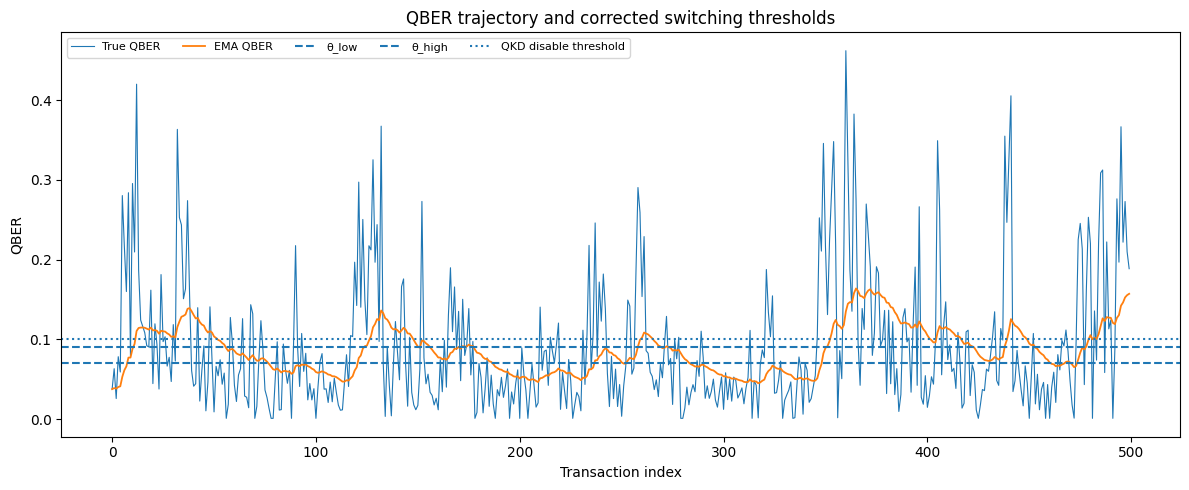

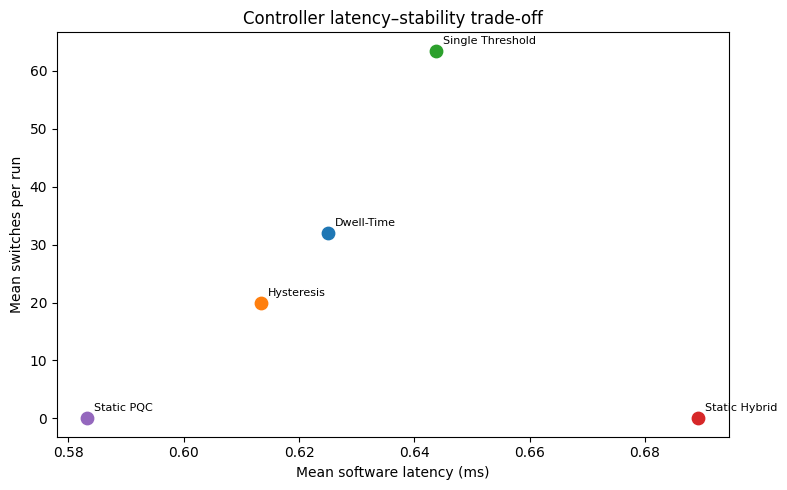

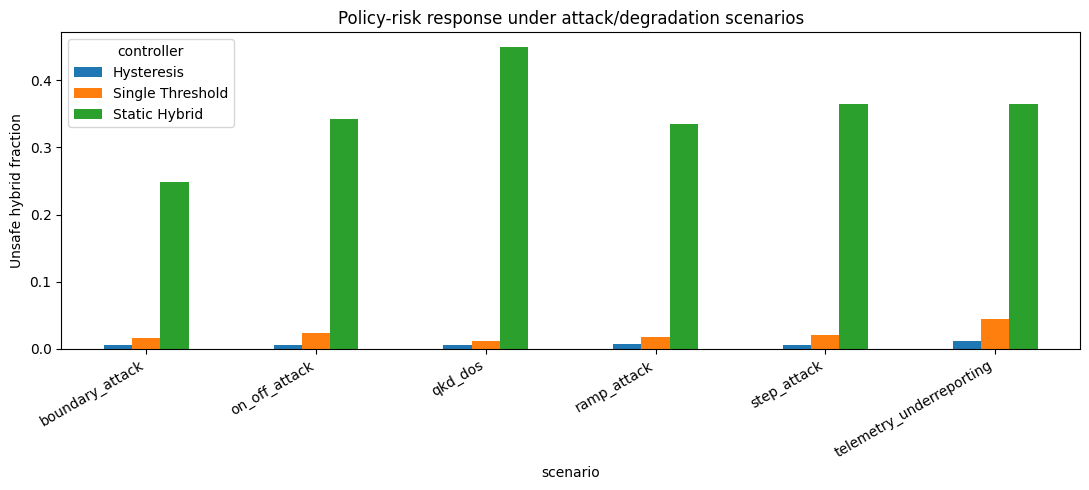

Figures saved in /content/qber_rtgs_outputs/figures


In [24]:
# CELL 22 — Figures
FIG_DIR = Path("/content/qber_rtgs_outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1: QBER, EMA, thresholds and mode
plot_df = demo_trace.iloc[:800].copy()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["t"], plot_df["qber_true"], linewidth=0.8, label="True QBER")
ax.plot(plot_df["t"], plot_df["qber_ema"], linewidth=1.3, label="EMA QBER")
ax.axhline(THETA_LOW, linestyle="--", label="θ_low")
ax.axhline(THETA_HIGH, linestyle="--", label="θ_high")
ax.axhline(QKD_DISABLE_QBER, linestyle=":", label="QKD disable threshold")
ax.set_xlabel("Transaction index")
ax.set_ylabel("QBER")
ax.set_title("QBER trajectory and corrected switching thresholds")
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR/"qber_thresholds.png", dpi=300)
plt.show()

# Figure 2: baseline trade-off
agg = baseline_runs.groupby("controller").agg(
    mean_latency_ms=("mean_latency_ms", "mean"),
    switches=("switches", "mean"),
    unsafe=("unsafe_hybrid_fraction", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for _, r in agg.iterrows():
    ax.scatter(r["mean_latency_ms"], r["switches"], s=80)
    ax.annotate(r["controller"], (r["mean_latency_ms"], r["switches"]), xytext=(5,5),
                textcoords="offset points", fontsize=8)
ax.set_xlabel("Mean software latency (ms)")
ax.set_ylabel("Mean switches per run")
ax.set_title("Controller latency–stability trade-off")
fig.tight_layout()
fig.savefig(FIG_DIR/"controller_tradeoff.png", dpi=300)
plt.show()

# Figure 3: attack unsafe fraction
# Start of added code to fix NameError for 'attack_summary'
attack_scenarios = [
    Scenario(name="step_attack", attack_type="step"),
    Scenario(name="ramp_attack", attack_type="ramp"),
    Scenario(name="on_off_attack", attack_type="on_off"),
    Scenario(name="boundary_attack", attack_type="boundary"),
    Scenario(name="qkd_dos", attack_type="dos"),
    Scenario(name="telemetry_underreporting", attack_type="step", telemetry_bias=-0.035),
]

attack_runs = pd.concat(
    [run_experiment(s, n_runs=N_RUNS) for s in attack_scenarios],
    ignore_index=True
)

attack_summary = (
    attack_runs.groupby(["scenario", "controller"])
    .agg(
        mean_latency_ms=("mean_latency_ms", "mean"),
        switches=("switches", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        fallback_delay_tx=("attack_fallback_delay_tx", "mean"),
        key_starvation_events=("key_starvation_events", "mean"),
    )
    .reset_index()
)
# End of added code

attack_plot = attack_summary[attack_summary.controller.isin(["Hysteresis","Single Threshold","Static Hybrid"])]
pivot = attack_plot.pivot(index="scenario", columns="controller", values="unsafe_hybrid_fraction")
ax = pivot.plot(kind="bar", figsize=(11,5))
ax.set_ylabel("Unsafe hybrid fraction")
ax.set_title("Policy-risk response under attack/degradation scenarios")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR/"attack_unsafe_fraction.png", dpi=300)
plt.show()

print(f"Figures saved in {FIG_DIR}")


## 20. Export  tables and full experiment records


In [25]:

# CELL 23 — Export results
OUT_DIR = Path("/content/qber_rtgs_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "main_results": main_table,
    "paired_tests": tests_df,
    "attack_summary": attack_summary,
    "ablation": ablation_table,
    "sensitivity": sensitivity_table,
    "threshold_sweep": threshold_table,
    "reproducibility": repro_table,
    "baseline_run_records": baseline_runs,
    "attack_run_records": attack_runs,
    "ablation_run_records": ablation_runs,
    "sensitivity_run_records": sensitivity_runs,
}

for name, frame in tables.items():
    frame.to_csv(OUT_DIR/f"{name}.csv", index=False)

with pd.ExcelWriter(OUT_DIR/"manuscript_tables.xlsx", engine="openpyxl") as writer:
    for name, frame in tables.items():
        frame.to_excel(writer, sheet_name=name[:31], index=False)

metadata = {
    "configuration": {
        "PAPER_MODE": PAPER_MODE,
        "MASTER_SEED": MASTER_SEED,
        "N_TX": N_TX,
        "N_RUNS": N_RUNS,
        "THETA_LOW": THETA_LOW,
        "THETA_HIGH": THETA_HIGH,
        "QKD_DISABLE_QBER": QKD_DISABLE_QBER,
        "EMA_ALPHA": EMA_ALPHA,
        "RECOVERY_DWELL": RECOVERY_DWELL,
    },
    "dataset_source": DATA_SOURCE,
    "dataset_integrity": integrity,
    "interpretation": (
        "The DOI dataset is an archived synthetic benchmark trace. "
        "Cross-seed comparisons are reproducibility tests, not external validation."
    ),
}
with open(OUT_DIR/"experiment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"All tables and records exported to {OUT_DIR}")
print("Files:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(" -", p)


All tables and records exported to /content/qber_rtgs_outputs
Files:
 - /content/qber_rtgs_outputs/ablation.csv
 - /content/qber_rtgs_outputs/ablation_run_records.csv
 - /content/qber_rtgs_outputs/attack_run_records.csv
 - /content/qber_rtgs_outputs/attack_summary.csv
 - /content/qber_rtgs_outputs/baseline_run_records.csv
 - /content/qber_rtgs_outputs/experiment_metadata.json
 - /content/qber_rtgs_outputs/figures/attack_unsafe_fraction.png
 - /content/qber_rtgs_outputs/figures/controller_tradeoff.png
 - /content/qber_rtgs_outputs/figures/qber_thresholds.png
 - /content/qber_rtgs_outputs/main_results.csv
 - /content/qber_rtgs_outputs/manuscript_tables.xlsx
 - /content/qber_rtgs_outputs/paired_tests.csv
 - /content/qber_rtgs_outputs/reproducibility.csv
 - /content/qber_rtgs_outputs/sensitivity.csv
 - /content/qber_rtgs_outputs/sensitivity_run_records.csv
 - /content/qber_rtgs_outputs/threshold_sweep.csv


In [ ]:

# CELL 24 — Final consistency checks
assert THETA_LOW < THETA_HIGH <= QKD_DISABLE_QBER
assert QKD_DISABLE_QBER < root
assert set(baseline_runs["controller"]) == set(controller_factory().keys())
assert baseline_runs.groupby("controller")["run_id"].nunique().eq(N_RUNS).all()
assert not baseline_runs[["mean_latency_ms", "switches", "unsafe_hybrid_fraction"]].isna().any().any()

print("All consistency checks passed.")
print("Notebook execution complete.")



# ADDITIONAL CORRECTIONS

Append-only implementation of:

1. Dual-source Hybrid benefit quantification.
2. Abundant, Balanced, and Constrained key-buffer regimes.
3. Immediate raw-QBER/SKR emergency fallback with EMA-only recovery.
4. Individual threshold-pair and Pareto-frontier analysis.


In [26]:
PAPER_MODE = True

In [27]:

# ADDITIONAL CELL A1 — Immediate-exit, smoothed-recovery controller

class ImmediateExitHysteresisController(BaseController):
    name = "Immediate-Exit Hysteresis"

    def __init__(
        self,
        theta_low=THETA_LOW,
        theta_high=THETA_HIGH,
        qkd_disable_qber=QKD_DISABLE_QBER,
        min_buffer=MIN_BUFFER_FOR_HYBRID,
        dwell=RECOVERY_DWELL,
    ):
        self.theta_low = float(theta_low)
        self.theta_high = float(theta_high)
        self.qkd_disable_qber = float(qkd_disable_qber)
        self.min_buffer = float(min_buffer)
        self.dwell = int(dwell)
        self.reset()

    def reset(self):
        self.mode = "PQC_ONLY"
        self.recovery_count = 0
        self.last_transition_reason = "initialization"

    def select(self, obs):
        q_raw = float(obs["qber_observed"])
        q_ema = float(obs["qber_ema"])
        key_fraction = float(obs["key_fraction"])
        buffer_level = float(obs["buffer"])

        raw_qber_unsafe = q_raw >= self.qkd_disable_qber
        skr_unavailable = key_fraction <= 0.0
        buffer_unavailable = buffer_level < self.min_buffer

        # Immediate safety exit: raw QBER/SKR/buffer; never wait for EMA.
        if self.mode == "HYBRID":
            if raw_qber_unsafe:
                self.mode = "PQC_ONLY"
                self.recovery_count = 0
                self.last_transition_reason = "raw_qber_emergency"
            elif skr_unavailable:
                self.mode = "PQC_ONLY"
                self.recovery_count = 0
                self.last_transition_reason = "skr_unavailable"
            elif buffer_unavailable:
                self.mode = "PQC_ONLY"
                self.recovery_count = 0
                self.last_transition_reason = "buffer_insufficient"

        # Conservative recovery: EMA and sustained dwell.
        else:
            recovery_safe = (
                q_raw < self.theta_high
                and q_ema <= self.theta_low
                and key_fraction > 0.0
                and buffer_level >= self.min_buffer
            )
            if recovery_safe:
                self.recovery_count += 1
                if self.recovery_count >= self.dwell:
                    self.mode = "HYBRID"
                    self.recovery_count = 0
                    self.last_transition_reason = "stable_recovery"
            else:
                self.recovery_count = 0

        return self.mode

print("ImmediateExitHysteresisController defined.")


ImmediateExitHysteresisController defined.


In [28]:

# ADDITIONAL CELL A2 — Key-supply regimes

KEY_SUPPLY_REGIMES = {
    "Abundant": {
        "generation_ratio_low": 1.50,
        "generation_ratio_high": 2.00,
        "initial_buffer_fraction": 0.60,
    },
    "Balanced": {
        "generation_ratio_low": 0.90,
        "generation_ratio_high": 1.10,
        "initial_buffer_fraction": 0.35,
    },
    "Constrained": {
        "generation_ratio_low": 0.30,
        "generation_ratio_high": 0.70,
        "initial_buffer_fraction": 0.12,
    },
}

KEY_REGIME_N_RUNS = 50 if PAPER_MODE else 5
KEY_REGIME_N_TX = 5000 if PAPER_MODE else min(N_TX, 1000)

display(pd.DataFrame(KEY_SUPPLY_REGIMES).T)
print("Runs per regime:", KEY_REGIME_N_RUNS)
print("Transactions per run:", KEY_REGIME_N_TX)


,generation_ratio_low,generation_ratio_high,initial_buffer_fraction
Abundant,1.5,2.0,0.60
Balanced,0.9,1.1,0.35
Constrained,0.3,0.7,0.12


Runs per regime: 50
Transactions per run: 5000


In [29]:

# ADDITIONAL CELL A3 — Configurable key-regime evaluator

def evaluate_controller_key_regime(
    channel_df,
    controller,
    regime_name,
    seed=MASTER_SEED,
    buffer_max=BUFFER_MAX,
    min_buffer=MIN_BUFFER_FOR_HYBRID,
    consumption_per_tx=KEY_CONSUMPTION_PER_TX,
):
    if regime_name not in KEY_SUPPLY_REGIMES:
        raise ValueError(f"Unknown regime: {regime_name}")

    params = KEY_SUPPLY_REGIMES[regime_name]
    rng = np.random.default_rng(seed)
    controller.reset()

    channel_df = channel_df.reset_index(drop=True)
    q_ema = ema_series(channel_df["qber_observed"].to_numpy())
    buffer = float(buffer_max * params["initial_buffer_fraction"])
    prev_mode = None

    below_threshold_time = 0
    forced_pqc_fallbacks = 0
    starvation_events = 0
    recovery_durations = []
    waiting_for_recovery = False
    recovery_start = None
    rows = []

    for i, row in channel_df.iterrows():
        q_true = float(row["qber_true"])
        q_observed = float(row["qber_observed"])
        key_fraction = float(row["key_fraction"])

        generation_ratio = rng.uniform(
            params["generation_ratio_low"],
            params["generation_ratio_high"],
        )

        # Generation relative to one transaction's consumption,
        # modulated by available secret-key fraction.
        generated_key_units = (
            consumption_per_tx
            * generation_ratio
            * max(key_fraction, 0.0)
        )
        buffer_before_generation = buffer
        buffer = min(buffer_max, buffer + generated_key_units)

        if buffer < min_buffer:
            below_threshold_time += 1

        obs = {
            "qber_observed": q_observed,
            "qber_ema": float(q_ema[i]),
            "key_fraction": key_fraction,
            "buffer": buffer,
        }

        requested_mode = controller.select(obs)
        selected_mode = requested_mode
        forced_fallback = False
        starvation = False

        if requested_mode == "HYBRID":
            if buffer >= consumption_per_tx:
                buffer -= consumption_per_tx
            else:
                selected_mode = "PQC_ONLY"
                forced_fallback = True
                starvation = True
                starvation_events += 1
                forced_pqc_fallbacks += 1
                if hasattr(controller, "mode"):
                    controller.mode = "PQC_ONLY"
                if hasattr(controller, "recovery_count"):
                    controller.recovery_count = 0

        if (
            prev_mode == "HYBRID"
            and selected_mode == "PQC_ONLY"
            and buffer < min_buffer
            and not forced_fallback
        ):
            forced_pqc_fallbacks += 1

        if prev_mode == "HYBRID" and selected_mode == "PQC_ONLY":
            waiting_for_recovery = True
            recovery_start = i

        if (
            waiting_for_recovery
            and prev_mode == "PQC_ONLY"
            and selected_mode == "HYBRID"
        ):
            recovery_durations.append(i - recovery_start)
            waiting_for_recovery = False
            recovery_start = None

        raw_qkd_usable = (
            q_true < QKD_DISABLE_QBER
            and key_fraction > 0.0
            and buffer >= 0.0
        )
        unsafe_hybrid = bool(
            selected_mode == "HYBRID" and not raw_qkd_usable
        )
        switch = int(prev_mode is not None and selected_mode != prev_mode)
        latency = sample_latency(selected_mode, rng)

        rows.append({
            **row.to_dict(),
            "regime": regime_name,
            "qber_ema": float(q_ema[i]),
            "generation_ratio": generation_ratio,
            "generated_key_units": generated_key_units,
            "buffer_before_generation": buffer_before_generation,
            "buffer": buffer,
            "requested_mode": requested_mode,
            "mode_selected": selected_mode,
            "latency_ms": latency,
            "switch": switch,
            "unsafe_hybrid": unsafe_hybrid,
            "key_starvation": starvation,
            "forced_pqc_fallback": forced_fallback,
            "below_buffer_threshold": buffer < min_buffer,
        })
        prev_mode = selected_mode

    trace = pd.DataFrame(rows)

    summary = {
        "regime": regime_name,
        "controller": controller.name,
        "mean_latency_ms": trace["latency_ms"].mean(),
        "p95_latency_ms": trace["latency_ms"].quantile(0.95),
        "switches": int(trace["switch"].sum()),
        "hybrid_availability": trace["mode_selected"].eq("HYBRID").mean(),
        "pqc_availability": trace["mode_selected"].eq("PQC_ONLY").mean(),
        "dual_source_protection_fraction": (
            trace["mode_selected"].eq("HYBRID")
            & ~trace["unsafe_hybrid"]
        ).mean(),
        "unsafe_hybrid_fraction": trace["unsafe_hybrid"].mean(),
        "starvation_events": int(starvation_events),
        "buffer_minimum": float(trace["buffer"].min()),
        "time_below_threshold_tx": int(below_threshold_time),
        "time_below_threshold_fraction": float(
            trace["below_buffer_threshold"].mean()
        ),
        "forced_pqc_fallbacks": int(forced_pqc_fallbacks),
        "mean_recovery_time_tx": (
            float(np.mean(recovery_durations))
            if recovery_durations else np.nan
        ),
        "median_recovery_time_tx": (
            float(np.median(recovery_durations))
            if recovery_durations else np.nan
        ),
        "p95_recovery_time_tx": (
            float(np.quantile(recovery_durations, 0.95))
            if recovery_durations else np.nan
        ),
        "max_recovery_time_tx": (
            float(np.max(recovery_durations))
            if recovery_durations else np.nan
        ),
        "completed_recoveries": len(recovery_durations),
    }

    return trace, summary

print("Key-regime evaluator defined.")


Key-regime evaluator defined.


In [30]:

# ADDITIONAL CELL A4 — Run key-buffer experiments

key_regime_summaries = []
key_regime_traces = {}

for regime_name in KEY_SUPPLY_REGIMES:
    print(f"Running regime: {regime_name}")

    for run_id in range(KEY_REGIME_N_RUNS):
        seed = MASTER_SEED + 70000 + 1019 * run_id

        channel = simulate_channel(
            n_tx=KEY_REGIME_N_TX,
            seed=seed,
            scenario=Scenario(name=f"key_regime_{regime_name.lower()}"),
        )

        controllers = {
            "Immediate-Exit Hysteresis": ImmediateExitHysteresisController(),
            "Original Hysteresis": HysteresisController(),
            "Static PQC": StaticPQC(),
            "Static Hybrid": StaticHybrid(),
        }

        for controller_label, controller in controllers.items():
            trace, summary = evaluate_controller_key_regime(
                channel_df=channel,
                controller=controller,
                regime_name=regime_name,
                seed=seed + 37,
            )
            summary["controller"] = controller_label
            summary["run_id"] = run_id
            summary["seed"] = seed
            key_regime_summaries.append(summary)

            if run_id == 0:
                key_regime_traces[(regime_name, controller_label)] = trace

key_regime_runs = pd.DataFrame(key_regime_summaries)

key_regime_table = (
    key_regime_runs
    .groupby(["regime", "controller"], as_index=False)
    .agg(
        mean_latency_ms=("mean_latency_ms", "mean"),
        switches=("switches", "mean"),
        starvation_events=("starvation_events", "mean"),
        buffer_minimum=("buffer_minimum", "mean"),
        time_below_threshold_tx=("time_below_threshold_tx", "mean"),
        time_below_threshold_fraction=("time_below_threshold_fraction", "mean"),
        forced_pqc_fallbacks=("forced_pqc_fallbacks", "mean"),
        hybrid_availability=("hybrid_availability", "mean"),
        dual_source_protection_fraction=("dual_source_protection_fraction", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        mean_recovery_time_tx=("mean_recovery_time_tx", "mean"),
        p95_recovery_time_tx=("p95_recovery_time_tx", "mean"),
        max_recovery_time_tx=("max_recovery_time_tx", "mean"),
    )
)

display(key_regime_table.round(6))


Running regime: Abundant
Running regime: Balanced
Running regime: Constrained


,regime,controller,mean_latency_ms,switches,starvation_events,buffer_minimum,time_below_threshold_tx,time_below_threshold_fraction,forced_pqc_fallbacks,hybrid_availability,dual_source_protection_fraction,unsafe_hybrid_fraction,mean_recovery_time_tx,p95_recovery_time_tx,max_recovery_time_tx
0,Abundant,Immediate-Exit Hysteresis,0.591231,202.84,0.00,1500.536715,0.00,0.000000,0.00,0.195980,0.195980,0.000000,39.642581,143.286,282.22
1,Abundant,Original Hysteresis,0.594239,205.72,0.00,1500.517828,0.00,0.000000,0.00,0.226496,0.220328,0.006168,37.616878,137.404,273.56
2,Abundant,Static Hybrid,0.662319,209.58,267.68,0.005359,821.54,0.164836,267.68,0.946464,0.706364,0.240100,2.561221,7.812,14.58
3,Abundant,Static PQC,0.572973,0.00,0.00,1500.566270,0.00,0.000000,0.00,0.000000,0.000000,0.000000,NaN,NaN,NaN
4,Balanced,Immediate-Exit Hysteresis,0.591231,202.84,0.00,872.619451,0.00,0.000000,0.00,0.195980,0.195980,0.000000,39.642581,143.286,282.22
5,Balanced,Original Hysteresis,0.594239,205.72,0.00,871.272001,0.00,0.000000,0.00,0.226496,0.220328,0.006168,37.616878,137.404,273.56
6,Balanced,Static Hybrid,0.624370,1900.68,2278.02,0.000347,3651.36,0.730600,2278.02,0.544396,0.467016,0.077380,2.395809,7.588,22.08
7,Balanced,Static PQC,0.572973,0.00,0.00,875.325633,0.00,0.000000,0.00,0.000000,0.000000,0.000000,NaN,NaN,NaN
8,Constrained,Immediate-Exit Hysteresis,0.591216,202.92,0.00,195.136180,0.52,0.000144,0.14,0.195876,0.195876,0.000000,39.637149,143.286,282.22
9,Constrained,Original Hysteresis,0.593752,211.80,0.00,95.815117,21.44,0.005996,6.64,0.220908,0.214944,0.005964,37.038415,136.058,273.78


In [31]:

# ADDITIONAL CELL A5 — Dual-source benefit and operational cost

dual_source_tradeoff = (
    key_regime_runs
    .groupby(["regime", "controller"], as_index=False)
    .agg(
        dual_source_protection_fraction=("dual_source_protection_fraction", "mean"),
        hybrid_availability=("hybrid_availability", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        mean_latency_ms=("mean_latency_ms", "mean"),
        switches=("switches", "mean"),
        starvation_events=("starvation_events", "mean"),
        forced_pqc_fallbacks=("forced_pqc_fallbacks", "mean"),
    )
)

for col in [
    "dual_source_protection_fraction",
    "hybrid_availability",
    "unsafe_hybrid_fraction",
]:
    dual_source_tradeoff[col.replace("_fraction", "_pct")] = (
        100.0 * dual_source_tradeoff[col]
    )

display(
    dual_source_tradeoff
    .sort_values(["regime", "controller"])
    .round(6)
)

incremental_rows = []

for regime in KEY_SUPPLY_REGIMES:
    subset = dual_source_tradeoff[
        dual_source_tradeoff["regime"] == regime
    ].set_index("controller")

    if (
        "Immediate-Exit Hysteresis" in subset.index
        and "Static PQC" in subset.index
    ):
        proposed = subset.loc["Immediate-Exit Hysteresis"]
        static_pqc = subset.loc["Static PQC"]

        incremental_rows.append({
            "regime": regime,
            "additional_dual_source_protection_pct":
                proposed["dual_source_protection_pct"]
                - static_pqc["dual_source_protection_pct"],
            "latency_cost_ms_vs_static_pqc":
                proposed["mean_latency_ms"]
                - static_pqc["mean_latency_ms"],
            "additional_switches_vs_static_pqc":
                proposed["switches"] - static_pqc["switches"],
            "unsafe_hybrid_cost_pct":
                proposed["unsafe_hybrid_pct"]
                - static_pqc["unsafe_hybrid_pct"],
            "starvation_difference":
                proposed["starvation_events"]
                - static_pqc["starvation_events"],
        })

incremental_dual_source_benefit = pd.DataFrame(incremental_rows)
display(incremental_dual_source_benefit.round(6))


,regime,controller,dual_source_protection_fraction,hybrid_availability,unsafe_hybrid_fraction,mean_latency_ms,switches,starvation_events,forced_pqc_fallbacks,dual_source_protection_pct,unsafe_hybrid_pct
0,Abundant,Immediate-Exit Hysteresis,0.195980,19.5980,0.000000,0.591231,202.84,0.00,0.00,19.5980,0.0000
1,Abundant,Original Hysteresis,0.220328,22.6496,0.006168,0.594239,205.72,0.00,0.00,22.0328,0.6168
2,Abundant,Static Hybrid,0.706364,94.6464,0.240100,0.662319,209.58,267.68,267.68,70.6364,24.0100
3,Abundant,Static PQC,0.000000,0.0000,0.000000,0.572973,0.00,0.00,0.00,0.0000,0.0000
4,Balanced,Immediate-Exit Hysteresis,0.195980,19.5980,0.000000,0.591231,202.84,0.00,0.00,19.5980,0.0000
5,Balanced,Original Hysteresis,0.220328,22.6496,0.006168,0.594239,205.72,0.00,0.00,22.0328,0.6168
6,Balanced,Static Hybrid,0.467016,54.4396,0.077380,0.624370,1900.68,2278.02,2278.02,46.7016,7.7380
7,Balanced,Static PQC,0.000000,0.0000,0.000000,0.572973,0.00,0.00,0.00,0.0000,0.0000
8,Constrained,Immediate-Exit Hysteresis,0.195876,19.5876,0.000000,0.591216,202.92,0.00,0.14,19.5876,0.0000
9,Constrained,Original Hysteresis,0.214944,22.0908,0.005964,0.593752,211.80,0.00,6.64,21.4944,0.5964


,regime,additional_dual_source_protection_pct,latency_cost_ms_vs_static_pqc,additional_switches_vs_static_pqc,unsafe_hybrid_cost_pct,starvation_difference
0,Abundant,19.5980,0.018257,202.84,0.0,0.0
1,Balanced,19.5980,0.018257,202.84,0.0,0.0
2,Constrained,19.5876,0.018243,202.92,0.0,0.0


In [32]:

# ADDITIONAL CELL A6 — Immediate emergency fallback validation

EMERGENCY_N_RUNS = 50 if PAPER_MODE else 5
EMERGENCY_N_TX = 5000 if PAPER_MODE else min(N_TX, 1000)

emergency_scenarios = [
    Scenario(
        name="step_emergency",
        attack_type="step",
        attack_start=max(50, int(0.30 * EMERGENCY_N_TX)),
        attack_duration=max(100, int(0.20 * EMERGENCY_N_TX)),
    ),
    Scenario(
        name="qkd_dos_emergency",
        attack_type="dos",
        attack_start=max(50, int(0.30 * EMERGENCY_N_TX)),
        attack_duration=max(100, int(0.20 * EMERGENCY_N_TX)),
    ),
]

emergency_rows = []

for scenario in emergency_scenarios:
    print("Running:", scenario.name)

    for run_id in range(EMERGENCY_N_RUNS):
        seed = MASTER_SEED + 90000 + 1021 * run_id
        channel = simulate_channel(
            n_tx=EMERGENCY_N_TX,
            seed=seed,
            scenario=scenario,
        )

        for label, controller in {
            "Immediate-Exit Hysteresis": ImmediateExitHysteresisController(),
            "Original EMA-Exit Hysteresis": HysteresisController(),
        }.items():
            trace = evaluate_controller(channel, controller, seed=seed + 11)

            unsafe_condition = (
                (trace["qber_true"] >= QKD_DISABLE_QBER)
                | (trace["key_fraction"] <= 0.0)
            )
            violation = unsafe_condition & trace["mode_selected"].eq("HYBRID")

            attack_positions = np.flatnonzero(trace["attack_active"].to_numpy())
            fallback_delay = np.nan
            if len(attack_positions):
                attack_start = int(attack_positions[0])
                fallback_after_attack = np.flatnonzero(
                    (
                        trace["mode_selected"].eq("PQC_ONLY")
                        & (trace.index >= attack_start)
                    ).to_numpy()
                )
                if len(fallback_after_attack):
                    fallback_delay = int(
                        fallback_after_attack[0] - attack_start
                    )

            emergency_rows.append({
                "scenario": scenario.name,
                "controller": label,
                "run_id": run_id,
                "seed": seed,
                "fallback_delay_tx": fallback_delay,
                "safety_invariant_violations": int(violation.sum()),
                "unsafe_hybrid_fraction": float(trace["unsafe_hybrid"].mean()),
                "switches": int(trace["switch"].sum()),
                "mean_latency_ms": float(trace["latency_ms"].mean()),
            })

emergency_runs = pd.DataFrame(emergency_rows)

emergency_summary = (
    emergency_runs
    .groupby(["scenario", "controller"], as_index=False)
    .agg(
        mean_fallback_delay_tx=("fallback_delay_tx", "mean"),
        median_fallback_delay_tx=("fallback_delay_tx", "median"),
        p95_fallback_delay_tx=("fallback_delay_tx", lambda x: np.nanquantile(x, 0.95)),
        max_fallback_delay_tx=("fallback_delay_tx", "max"),
        mean_safety_invariant_violations=("safety_invariant_violations", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        switches=("switches", "mean"),
        mean_latency_ms=("mean_latency_ms", "mean"),
    )
)

display(emergency_summary.round(6))


Running: step_emergency
Running: qkd_dos_emergency


,scenario,controller,mean_fallback_delay_tx,median_fallback_delay_tx,p95_fallback_delay_tx,max_fallback_delay_tx,mean_safety_invariant_violations,unsafe_hybrid_fraction,switches,mean_latency_ms
0,qkd_dos_emergency,Immediate-Exit Hysteresis,0.00,0.0,0.0,0,0.00,0.000000,162.52,0.588931
1,qkd_dos_emergency,Original EMA-Exit Hysteresis,0.00,0.0,0.0,0,23.50,0.004700,164.92,0.591295
2,step_emergency,Immediate-Exit Hysteresis,0.38,0.0,3.0,5,0.00,0.000000,162.76,0.588959
3,step_emergency,Original EMA-Exit Hysteresis,0.76,0.0,4.0,14,23.66,0.004732,165.20,0.591336


In [33]:

# ADDITIONAL CELL A7 — Individual threshold-pair evaluation

PARETO_N_RUNS = 30 if PAPER_MODE else 3
PARETO_N_TX = 5000 if PAPER_MODE else min(N_TX, 1000)

THRESHOLD_PAIRS = [
    (0.04, 0.07),
    (0.04, 0.08),
    (0.05, 0.08),
    (0.05, 0.09),
    (0.06, 0.08),
    (0.06, 0.09),
    (0.06, 0.10),
    (0.07, 0.09),
    (0.07, 0.10),
    (0.08, 0.10),
]

threshold_pair_rows = []

for theta_low_v2, theta_high_v2 in THRESHOLD_PAIRS:
    if not (0 < theta_low_v2 < theta_high_v2 <= QKD_DISABLE_QBER):
        continue

    print(f"Evaluating ({theta_low_v2:.2f}, {theta_high_v2:.2f})")

    for run_id in range(PARETO_N_RUNS):
        seed = MASTER_SEED + 120000 + 1031 * run_id
        channel = simulate_channel(
            n_tx=PARETO_N_TX,
            seed=seed,
            scenario=Scenario(name="pareto_validation"),
        )

        controller = ImmediateExitHysteresisController(
            theta_low=theta_low_v2,
            theta_high=theta_high_v2,
        )

        trace, summary = evaluate_controller_key_regime(
            channel_df=channel,
            controller=controller,
            regime_name="Balanced",
            seed=seed + 13,
        )

        threshold_pair_rows.append({
            "theta_low": theta_low_v2,
            "theta_high": theta_high_v2,
            "run_id": run_id,
            "seed": seed,
            **summary,
        })

threshold_pair_runs = pd.DataFrame(threshold_pair_rows)

threshold_pair_table = (
    threshold_pair_runs
    .groupby(["theta_low", "theta_high"], as_index=False)
    .agg(
        mean_latency_ms=("mean_latency_ms", "mean"),
        mean_switches=("switches", "mean"),
        unsafe_hybrid_fraction=("unsafe_hybrid_fraction", "mean"),
        dual_source_protection_fraction=("dual_source_protection_fraction", "mean"),
        starvation_events=("starvation_events", "mean"),
        forced_pqc_fallbacks=("forced_pqc_fallbacks", "mean"),
        mean_recovery_time_tx=("mean_recovery_time_tx", "mean"),
    )
)

display(threshold_pair_table.round(6))


Evaluating (0.04, 0.07)
Evaluating (0.04, 0.08)
Evaluating (0.05, 0.08)
Evaluating (0.05, 0.09)
Evaluating (0.06, 0.08)
Evaluating (0.06, 0.09)
Evaluating (0.06, 0.10)
Evaluating (0.07, 0.09)
Evaluating (0.07, 0.10)
Evaluating (0.08, 0.10)


,theta_low,theta_high,mean_latency_ms,mean_switches,unsafe_hybrid_fraction,dual_source_protection_fraction,starvation_events,forced_pqc_fallbacks,mean_recovery_time_tx
0,0.04,0.07,0.575230,8.566667,0.0,0.009113,0.0,0.0,972.825000
1,0.04,0.08,0.575293,9.033333,0.0,0.009700,0.0,0.0,886.128526
2,0.05,0.08,0.579870,54.333333,0.0,0.059380,0.0,0.0,173.040108
3,0.05,0.09,0.580100,56.066667,0.0,0.061180,0.0,0.0,168.500227
4,0.06,0.08,0.586548,124.866667,0.0,0.131907,0.0,0.0,69.467699
5,0.06,0.09,0.587113,132.400000,0.0,0.137873,0.0,0.0,65.118577
6,0.06,0.10,0.587324,138.666667,0.0,0.141380,0.0,0.0,61.864681
7,0.07,0.09,0.594207,209.700000,0.0,0.211680,0.0,0.0,37.549949
8,0.07,0.10,0.594824,222.633333,0.0,0.219427,0.0,0.0,35.116820
9,0.08,0.10,0.600964,290.000000,0.0,0.282040,0.0,0.0,24.762236


In [34]:

# ADDITIONAL CELL A8 — Multi-objective score and Pareto frontier

def minmax_normalize(series):
    series = pd.Series(series, dtype=float)
    lo = series.min()
    hi = series.max()
    if np.isclose(hi, lo):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - lo) / (hi - lo)

def pareto_efficient_mask(frame, minimize_columns, maximize_columns):
    work = frame.copy().reset_index(drop=True)
    objective_matrix = []

    for col in minimize_columns:
        objective_matrix.append(work[col].to_numpy(dtype=float))
    for col in maximize_columns:
        objective_matrix.append(-work[col].to_numpy(dtype=float))

    values = np.column_stack(objective_matrix)
    efficient = np.ones(len(values), dtype=bool)

    for i in range(len(values)):
        for j in range(len(values)):
            if i == j:
                continue
            no_worse = np.all(values[j] <= values[i])
            strictly_better = np.any(values[j] < values[i])
            if no_worse and strictly_better:
                efficient[i] = False
                break

    return efficient

scored_thresholds = threshold_pair_table.copy()

scored_thresholds["latency_norm"] = minmax_normalize(
    scored_thresholds["mean_latency_ms"]
)
scored_thresholds["switch_norm"] = minmax_normalize(
    scored_thresholds["mean_switches"]
)
scored_thresholds["unsafe_norm"] = minmax_normalize(
    scored_thresholds["unsafe_hybrid_fraction"]
)
scored_thresholds["starvation_norm"] = minmax_normalize(
    scored_thresholds["starvation_events"]
)
scored_thresholds["dual_source_unavailability_norm"] = (
    1.0 - minmax_normalize(
        scored_thresholds["dual_source_protection_fraction"]
    )
)

WEIGHTS_V2 = {
    "latency": 0.20,
    "switching": 0.15,
    "unsafe_hybrid": 0.35,
    "key_starvation": 0.10,
    "dual_source_unavailability": 0.20,
}

scored_thresholds["multiobjective_cost"] = (
    WEIGHTS_V2["latency"] * scored_thresholds["latency_norm"]
    + WEIGHTS_V2["switching"] * scored_thresholds["switch_norm"]
    + WEIGHTS_V2["unsafe_hybrid"] * scored_thresholds["unsafe_norm"]
    + WEIGHTS_V2["key_starvation"] * scored_thresholds["starvation_norm"]
    + WEIGHTS_V2["dual_source_unavailability"]
      * scored_thresholds["dual_source_unavailability_norm"]
)

scored_thresholds["pareto_efficient"] = pareto_efficient_mask(
    scored_thresholds,
    minimize_columns=[
        "mean_latency_ms",
        "mean_switches",
        "unsafe_hybrid_fraction",
        "starvation_events",
    ],
    maximize_columns=["dual_source_protection_fraction"],
)

pareto_frontier = (
    scored_thresholds[scored_thresholds["pareto_efficient"]]
    .sort_values(["unsafe_hybrid_fraction", "mean_latency_ms"])
    .reset_index(drop=True)
)

display(
    scored_thresholds[
        [
            "theta_low",
            "theta_high",
            "mean_latency_ms",
            "mean_switches",
            "unsafe_hybrid_fraction",
            "dual_source_protection_fraction",
            "starvation_events",
            "multiobjective_cost",
            "pareto_efficient",
        ]
    ]
    .sort_values("multiobjective_cost")
    .round(6)
)

print("Pareto-efficient threshold pairs:")
display(pareto_frontier.round(6))


,theta_low,theta_high,mean_latency_ms,mean_switches,unsafe_hybrid_fraction,dual_source_protection_fraction,starvation_events,multiobjective_cost,pareto_efficient
0,0.04,0.07,0.575230,8.566667,0.0,0.009113,0.0,0.200000,True
1,0.04,0.08,0.575293,9.033333,0.0,0.009700,0.0,0.200308,True
2,0.05,0.08,0.579870,54.333333,0.0,0.059380,0.0,0.223619,True
3,0.05,0.09,0.580100,56.066667,0.0,0.061180,0.0,0.225005,True
4,0.06,0.08,0.586548,124.866667,0.0,0.131907,0.0,0.259965,True
5,0.06,0.09,0.587113,132.400000,0.0,0.137873,0.0,0.263993,True
6,0.06,0.10,0.587324,138.666667,0.0,0.141380,0.0,0.266405,True
7,0.07,0.09,0.594207,209.700000,0.0,0.211680,0.0,0.306243,True
8,0.07,0.10,0.594824,222.633333,0.0,0.219427,0.0,0.312255,True
9,0.08,0.10,0.600964,290.000000,0.0,0.282040,0.0,0.350000,True


Pareto-efficient threshold pairs:


,theta_low,theta_high,mean_latency_ms,mean_switches,unsafe_hybrid_fraction,dual_source_protection_fraction,starvation_events,forced_pqc_fallbacks,mean_recovery_time_tx,latency_norm,switch_norm,unsafe_norm,starvation_norm,dual_source_unavailability_norm,multiobjective_cost,pareto_efficient
0,0.04,0.07,0.575230,8.566667,0.0,0.009113,0.0,0.0,972.825000,0.000000,0.000000,0.0,0.0,1.000000,0.200000,True
1,0.04,0.08,0.575293,9.033333,0.0,0.009700,0.0,0.0,886.128526,0.002446,0.001658,0.0,0.0,0.997850,0.200308,True
2,0.05,0.08,0.579870,54.333333,0.0,0.059380,0.0,0.0,173.040108,0.180308,0.162620,0.0,0.0,0.815824,0.223619,True
3,0.05,0.09,0.580100,56.066667,0.0,0.061180,0.0,0.0,168.500227,0.189214,0.168779,0.0,0.0,0.809228,0.225005,True
4,0.06,0.08,0.586548,124.866667,0.0,0.131907,0.0,0.0,69.467699,0.439808,0.413242,0.0,0.0,0.550087,0.259965,True
5,0.06,0.09,0.587113,132.400000,0.0,0.137873,0.0,0.0,65.118577,0.461735,0.440009,0.0,0.0,0.528225,0.263993,True
6,0.06,0.10,0.587324,138.666667,0.0,0.141380,0.0,0.0,61.864681,0.469942,0.462276,0.0,0.0,0.515377,0.266405,True
7,0.07,0.09,0.594207,209.700000,0.0,0.211680,0.0,0.0,37.549949,0.737412,0.714675,0.0,0.0,0.257798,0.306243,True
8,0.07,0.10,0.594824,222.633333,0.0,0.219427,0.0,0.0,35.116820,0.761386,0.760630,0.0,0.0,0.229414,0.312255,True
9,0.08,0.10,0.600964,290.000000,0.0,0.282040,0.0,0.0,24.762236,1.000000,1.000000,0.0,0.0,0.000000,0.350000,True


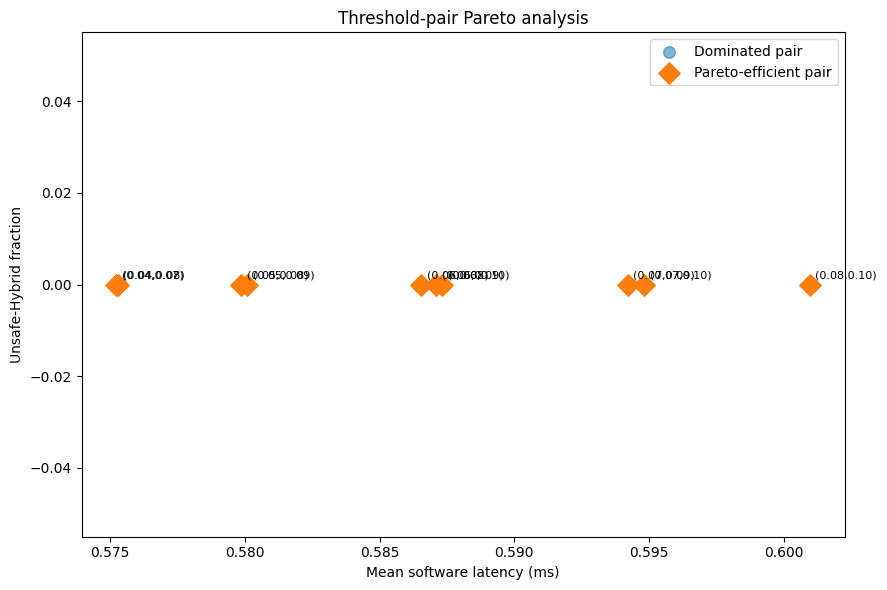

Saved all additional tables to: /content/qber_rtgs_outputs/additional_corrections


In [35]:

# ADDITIONAL CELL A9 — Pareto visualization and export

ADDITIONAL_OUTPUT_DIR = Path(
    "/content/qber_rtgs_outputs/additional_corrections"
)
ADDITIONAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 6))

non_pareto = scored_thresholds[~scored_thresholds["pareto_efficient"]]
pareto = scored_thresholds[scored_thresholds["pareto_efficient"]]

ax.scatter(
    non_pareto["mean_latency_ms"],
    non_pareto["unsafe_hybrid_fraction"],
    s=70,
    alpha=0.55,
    label="Dominated pair",
)
ax.scatter(
    pareto["mean_latency_ms"],
    pareto["unsafe_hybrid_fraction"],
    s=120,
    marker="D",
    label="Pareto-efficient pair",
)

for _, row in scored_thresholds.iterrows():
    ax.annotate(
        f"({row['theta_low']:.2f},{row['theta_high']:.2f})",
        (row["mean_latency_ms"], row["unsafe_hybrid_fraction"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Mean software latency (ms)")
ax.set_ylabel("Unsafe-Hybrid fraction")
ax.set_title("Threshold-pair Pareto analysis")
ax.legend()
fig.tight_layout()
fig.savefig(
    ADDITIONAL_OUTPUT_DIR / "threshold_pareto_frontier.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

additional_tables = {
    "key_regime_run_records": key_regime_runs,
    "key_regime_summary": key_regime_table,
    "dual_source_tradeoff": dual_source_tradeoff,
    "incremental_dual_source_benefit": incremental_dual_source_benefit,
    "emergency_run_records": emergency_runs,
    "emergency_summary": emergency_summary,
    "threshold_pair_run_records": threshold_pair_runs,
    "threshold_pair_summary": threshold_pair_table,
    "threshold_scored": scored_thresholds,
    "pareto_frontier": pareto_frontier,
}

for filename, frame in additional_tables.items():
    frame.to_csv(
        ADDITIONAL_OUTPUT_DIR / f"{filename}.csv",
        index=False,
    )

with pd.ExcelWriter(
    ADDITIONAL_OUTPUT_DIR / "additional_manuscript_tables.xlsx",
    engine="openpyxl",
) as writer:
    for sheet_name, frame in additional_tables.items():
        frame.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

print("Saved all additional tables to:", ADDITIONAL_OUTPUT_DIR)


In [36]:

# ADDITIONAL CELL A10 — Final consistency checks

required_key_metrics = {
    "starvation_events",
    "buffer_minimum",
    "time_below_threshold_tx",
    "forced_pqc_fallbacks",
    "hybrid_availability",
    "mean_recovery_time_tx",
    "dual_source_protection_fraction",
}

missing_metrics = required_key_metrics.difference(key_regime_runs.columns)
assert not missing_metrics, f"Missing metrics: {missing_metrics}"
assert (threshold_pair_table["theta_low"] < threshold_pair_table["theta_high"]).all()
assert (threshold_pair_table["theta_high"] <= QKD_DISABLE_QBER).all()
assert len(pareto_frontier) >= 1

print("All additional-correction consistency checks passed.")


All additional-correction consistency checks passed.
